# Week 3 복습 + 미니 프로젝트
실제 가상 CSV 데이터를 만들어 분석하고 정제한 뒤 시각화 리포트까지 완성하는 전체 파이프라인 코드를 설계

#### 미니 프로젝트 구조 핵심 요약
1. 1단계 (로드): 가상의 쇼핑몰 판매 데이터를 CSV 형식으로 만들어 불러옴
2. 2단계 (정제): 데이터 분석을 방해하는 빈칸(결측치)을 채우고, 똑같은 중복 데이터를 청소
3. 3단계 (분석): 전체 성적표(describe)를 확인하고, 특정 조건 필터링 및 카테고리별 요약을 수행
4. 4단계 (시각화): 분석한 결과를 선, 막대, 히스토그램으로 그려내어 보고서를 완성

In [19]:
# Week 3 복습 및 미니 프로젝트 - 쇼핑몰 판매 데이터 분석
!pip install matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 깨짐 방지 설정
plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

In [20]:
# [1단계 - 가상 CSV 파일 생성 및 로드]
# 가상의 CSV 파일을 먼저 만듬

raw_data = """
날짜,고객명,카테고리,수량,금액
2026-05-01,Bob,의류,2,50000
2026-05-01,Alice,전자제품,1,120000
2026-05-02,Bob,의류,2,50000
2026-05-02,Charlie,식품,5,25000
2026-05-03,David,전자제품,,300000
2026-05-03,Alice,식품,3,15000
2026-05-04,Eve,의류,1,25000
2026-05-04,Eve,의류,1,25000
"""

with open("sales_data.csv", "w", encoding='utf-8') as f:
    f.write(raw_data)

# CSV 파일 로드
df = pd.read_csv("sales_data.csv")
print("--- 1. 원본 데이터 로드 ---")
display(df)

--- 1. 원본 데이터 로드 ---


,날짜,고객명,카테고리,수량,금액
0,2026-05-01,Bob,의류,2.0,50000
1,2026-05-01,Alice,전자제품,1.0,120000
2,2026-05-02,Bob,의류,2.0,50000
3,2026-05-02,Charlie,식품,5.0,25000
4,2026-05-03,David,전자제품,NaN,300000
5,2026-05-03,Alice,식품,3.0,15000
6,2026-05-04,Eve,의류,1.0,25000
7,2026-05-04,Eve,의류,1.0,25000


In [21]:
# [2단계 - 데이터 정제 (Data Cleaning)]

print("\n--- 2. 데이터 정제 진행 ---")

# 데이터 타입 확인
print("[데이터 타입 확인]")
print(df.dtypes)

# 중복값 제거 (Eve의 동일한 날짜 의류 구매 중복 건 제거)
df = df.drop_duplicates()

# 결측치(NaN) 처리 (수량이 비어있는 David의 데이터를 수량 중앙값인 2로 채우기)
df['수량'] = df['수량'].fillna(df['수량'].median())

# 금액 컬럼을 정수형(int)으로 확실하게 정리
df['수량'] = df['수량'].astype(int)

print("\n[정제 완료 후 데이터]")
display(df)


--- 2. 데이터 정제 진행 ---
[데이터 타입 확인]
날짜       object
고객명      object
카테고리     object
수량      float64
금액        int64
dtype: object

[정제 완료 후 데이터]


,날짜,고객명,카테고리,수량,금액
0,2026-05-01,Bob,의류,2,50000
1,2026-05-01,Alice,전자제품,1,120000
2,2026-05-02,Bob,의류,2,50000
3,2026-05-02,Charlie,식품,5,25000
4,2026-05-03,David,전자제품,2,300000
5,2026-05-03,Alice,식품,3,15000
6,2026-05-04,Eve,의류,1,25000


In [22]:
# [3단계 - 데이터 분석 (Data Analysis)]

print("\n--- 3. 데이터 분석 및 요약 ---")

# 기본 통계량 확인
print("[전체 수치 데이터 기본 통계량]")
print(df.describe())

# 특정 조건 필터링: 금액이 3만원 이상인 판매 건만 추출
high_sales = df[df['금액'] >= 30000]
print("\n[필터링: 3만원 이상 판매 데이터]")
print(high_sales)

# 그룹별 분석: 카테고리별 총 금액 및 평균 수량 계산
category_summary = df.groupby('카테고리').agg({
    '금액': 'sum',
    '수량': 'mean'
}).reset_index()
print("\n[그룹화: 카테고리별 성과 요약]")
print(category_summary)


--- 3. 데이터 분석 및 요약 ---
[전체 수치 데이터 기본 통계량]
             수량             금액
count  7.000000       7.000000
mean   2.285714   83571.428571
std    1.380131  101641.292696
min    1.000000   15000.000000
25%    1.500000   25000.000000
50%    2.000000   50000.000000
75%    2.500000   85000.000000
max    5.000000  300000.000000

[필터링: 3만원 이상 판매 데이터]
           날짜    고객명  카테고리  수량      금액
0  2026-05-01    Bob    의류   2   50000
1  2026-05-01  Alice  전자제품   1  120000
2  2026-05-02    Bob    의류   2   50000
4  2026-05-03  David  전자제품   2  300000

[그룹화: 카테고리별 성과 요약]
   카테고리      금액        수량
0    식품   40000  4.000000
1    의류  125000  1.666667
2  전자제품  420000  1.500000


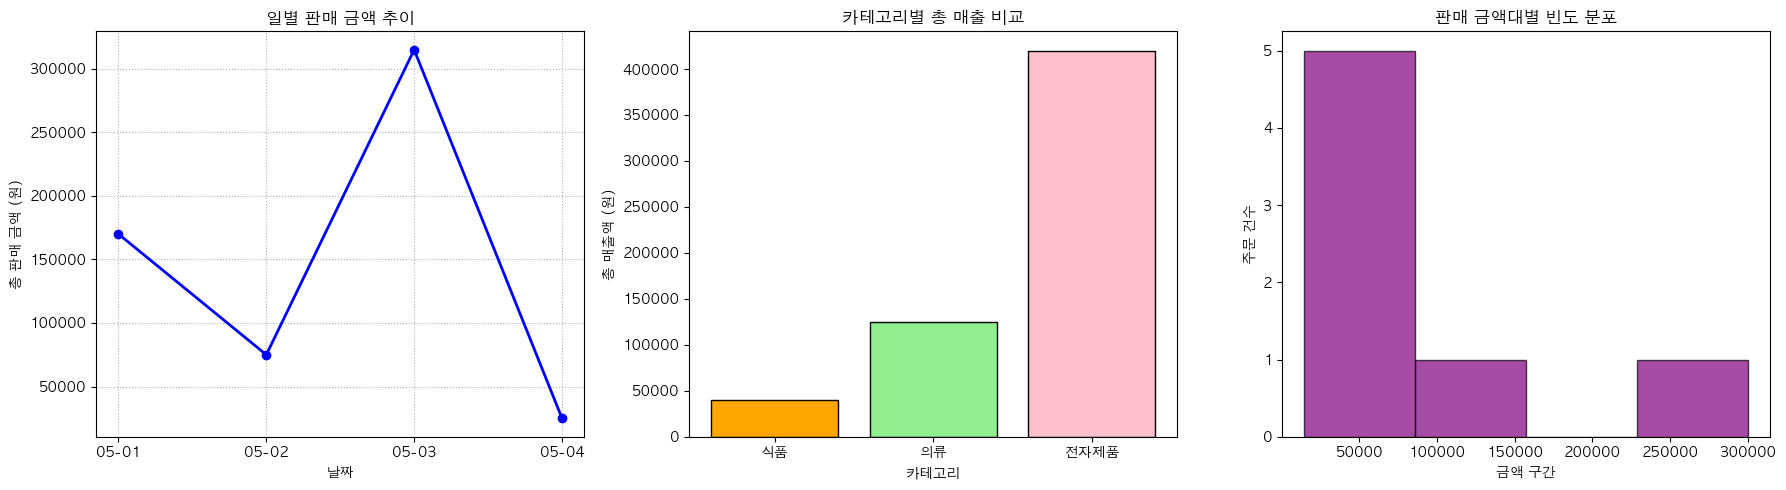

In [23]:
# [4단계 - 데이터 시각화 (Visualization)]
# 날짜별 매출 추이를 위한 시계열 데이터 가공

df['날짜'] = pd.to_datetime(df['날짜'])
daily_sales = df.groupby('날짜')['금액'].sum().reset_index()

# 1행 3열짜리 종합 대시보드 도화지 만들기
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) 판매 추이 (선 그래프)
axes[0].plot(daily_sales['날짜'].dt.strftime('%m-%d'), daily_sales['금액'], marker='o', color='b', linewidth=2)
axes[0].set_title("일별 판매 금액 추이")
axes[0].set_xlabel("날짜")
axes[0].set_ylabel("총 판매 금액 (원)")
axes[0].grid(True, linestyle=':')

# 2) 카테고리별 비교 (막대 그래프)
axes[1].bar(category_summary['카테고리'], category_summary['금액'], color=['orange', 'lightgreen', 'pink'], edgecolor='black')
axes[1].set_title("카테고리별 총 매출 비교")
axes[1].set_xlabel("카테고리")
axes[1].set_ylabel("총 매출액 (원)")

# 3) 금액 분포 (히스토그램)
axes[2].hist(df['금액'], bins=4, color='purple', edgecolor='black', alpha=0.7)
axes[2].set_title("판매 금액대별 빈도 분포")
axes[2].set_xlabel("금액 구간")
axes[2].set_ylabel("주문 건수")

plt.tight_layout()
plt.show()